<font color="skyblue">Defocus Blurring</font>

三段程式碼示範了Defocus blurring的概念，這是一種模擬相機對焦不準確時產生的模糊效果。

- 第一段程式碼使用 PyTorch 的卷積函數來模擬相機對焦不準確時的模糊效果。
- 第二段程式碼展示 OpenCV 的濾波器（也是卷積函數）來達成同樣的效果。
- 第三段程式碼則是使用了 Scipy 的卷積函數（convolve2d）。

<font color=yellow>1. Defocus blur by PyTorch</font>

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np

def circular_kernel(radius):
    size = 2 * radius + 1
    y, x = np.ogrid[-radius:radius+1, -radius:radius+1]
    mask = x**2 + y**2 <= radius**2
    kernel = np.zeros((size, size), dtype=np.float32)
    kernel[mask] = 1
    kernel /= kernel.sum()
    return torch.tensor(kernel, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

def defocus_blur_torch(img_tensor, radius=5):
    if img_tensor.dim() != 4:
        raise ValueError("img_tensor must have shape [N, C, H, W].")

    channels = img_tensor.shape[1]
    base_kernel = circular_kernel(radius).to(device=img_tensor.device, dtype=img_tensor.dtype)
    kernel = base_kernel.repeat(channels, 1, 1, 1)
    return F.conv2d(img_tensor, kernel, padding=radius, groups=channels)

# Example usage:
if __name__ == "__main__":
    import cv2
    import matplotlib.pyplot as plt

    img_path = 'pictures/lenna.png'  # Replace with your image path
    img = cv2.imread(img_path)
    img_tensor = torch.from_numpy(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)).permute(2, 0, 1).unsqueeze(0).float() / 255.0

    blurred_tensor = defocus_blur_torch(img_tensor, radius=8)
    blurred_img = blurred_tensor.squeeze(0).permute(1, 2, 0).numpy()

    plt.figure(figsize=(6, 3))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(blurred_img)
    plt.title("Defocus Blurred Image (PyTorch)")
    plt.axis("off")
    plt.show()

<font color=yellow>2. Defocus blur by OpenCV</font>

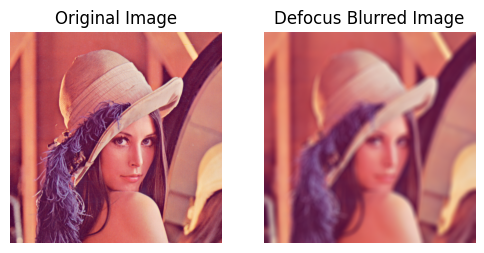

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def defocus_blur(img, radius=5):
    # 建立圓盤 kernel
    k = np.zeros((2*radius+1, 2*radius+1), np.float32)
    cv2.circle(k, (radius, radius), radius, 1, -1)
    k = k / k.sum()

    # 套用濾波
    return cv2.filter2D(img, -1, k)

img_path = "pictures/lenna.png"
img = cv2.imread(img_path)
blurred = defocus_blur(img, radius=8)
# cv2.imwrite("defocus.jpg", blurred)
# plot the original and blurred images in a side-by-side manner

plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
# img = cv2.imread(img_path)
# blurred = defocus_blur(img, radius=8)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB))
plt.title("Defocus Blurred Image")
plt.axis("off")
plt.show()


<font color=yellow>3. Defocus blur by Scipy</font>

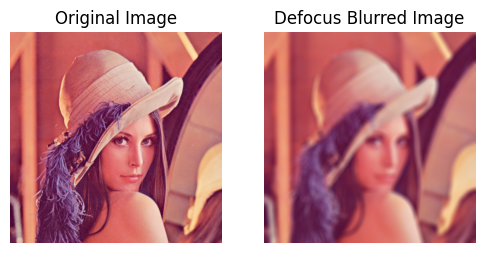

In [3]:
from scipy.signal import convolve2d
import numpy as np

def defocus_blur(img, radius=5):
    y, x = np.ogrid[-radius:radius+1, -radius:radius+1]
    mask = x**2 + y**2 <= radius**2
    kernel = mask.astype(np.float32)
    kernel /= kernel.sum()

    # convolve2d only supports 2D inputs, so process each color channel separately
    if img.ndim == 2:
        blurred = convolve2d(img, kernel, mode='same', boundary='symm')
    else:
        channels = [
            convolve2d(img[:, :, c], kernel, mode='same', boundary='symm')
            for c in range(img.shape[2])
        ]
        blurred = np.stack(channels, axis=2)

    return np.clip(blurred, 0, 255).astype(img.dtype)


img_path = "pictures/lenna.png"
img = cv2.imread(img_path)
blurred = defocus_blur(img, radius=8)
# cv2.imwrite("defocus.jpg", blurred)
# plot the original and blurred images in a side-by-side manner

plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB))
plt.title("Defocus Blurred Image")
plt.axis("off")
plt.show()
